###Problem Statement
You are given MNIST (https://www.kaggle.com/datasets/hojjatk/mnist-dataset),

which consists of handwritten digit images (0-9). Your task is to build a classi- fication pipeline using only the digits 0, 1, and 2. Randomly select 100 samples

from train set of each class leading to a total of 300 samples. Call this as train set. Randomly sample 100 samples from test set for each class and denote it as test set. This exercise incorporates the following concepts:

Principal Component Analysis (PCA): Reduce the dimensionality of the MNIST dataset while retaining 95% variance.
Fisher’s Discriminant Analysis (FDA): Find the optimal low-dimensional projection that maximizes class separation.
Discriminant Analysis for Classification: Use Linear Discriminant Analysis (LDA) or Quadratic Discriminant Analysis (QDA) to classify test samples.

--- 1. FDA Accuracy (on Test Set) ---
FDA+LDA: Train=0.9800, Test=0.9533
FDA+QDA: Train=0.9833, Test=0.9600

--- 2. PCA (75% Variance) + LDA ---
PCA(75%)+LDA: Train=0.9800, Test=0.9533

--- 3. PCA (90% Variance) + LDA ---
PCA(90%)+LDA: Test Accuracy=0.9433

--- 4. PCA (2 Components) + LDA ---
PCA(2nd)+LDA: Train=0.9000, Test=0.8900


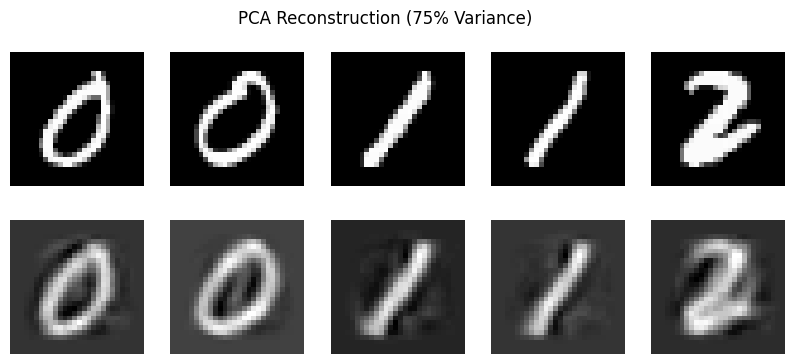

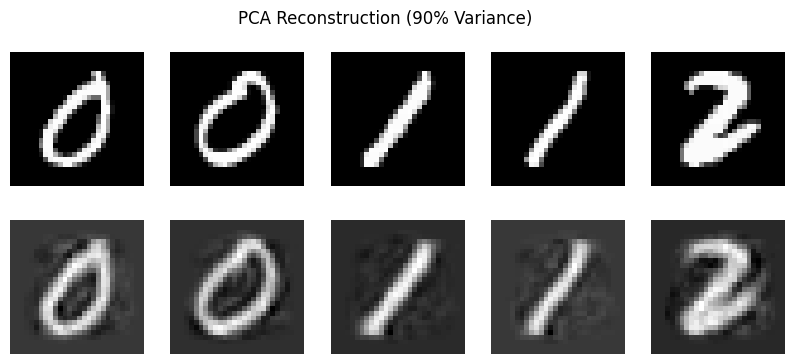

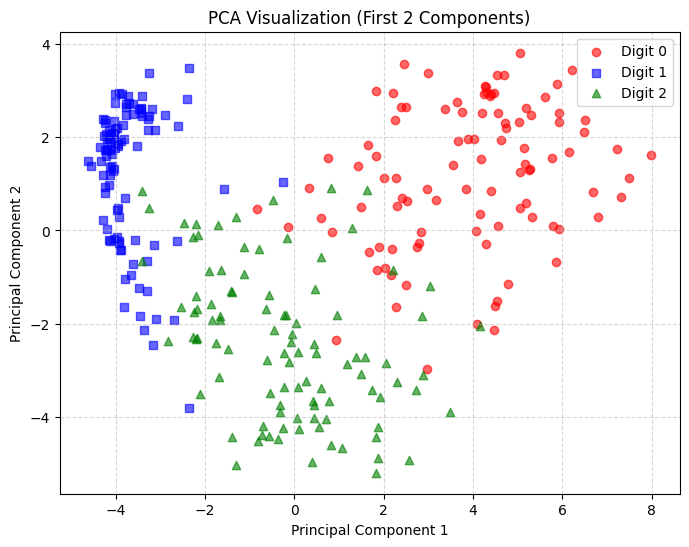

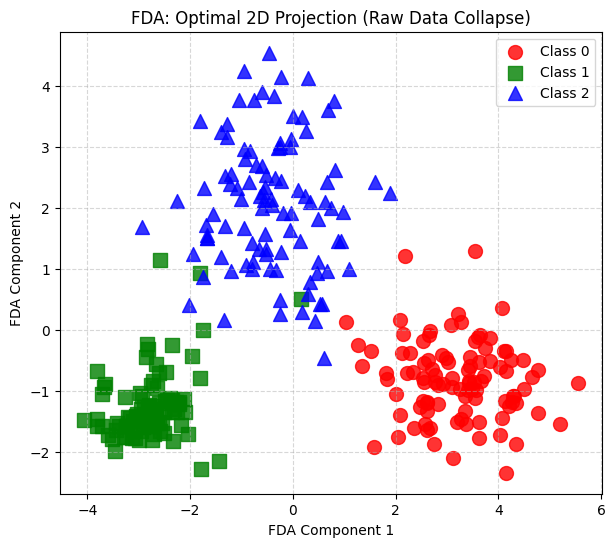

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# --- STEP 1: LOAD AND PREPARE DATA ---
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

all_images = np.concatenate([train_images, test_images], axis=0)
all_labels = np.concatenate([train_labels, test_labels], axis=0)

X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

for digit in [0, 1, 2]:
    indices = np.where(all_labels == digit)[0]
    selected_indices = np.random.choice(indices, 200, replace=False)

    X_train_list.append(all_images[selected_indices[:100]])
    y_train_list.append(all_labels[selected_indices[:100]])
    X_test_list.append(all_images[selected_indices[100:]])
    y_test_list.append(all_labels[selected_indices[100:]])

X_train_raw = np.concatenate(X_train_list).reshape(300, 784).T.astype(float) / 255.0
y_train = np.concatenate(y_train_list)
X_test_raw = np.concatenate(X_test_list).reshape(300, 784).T.astype(float) / 255.0
y_test = np.concatenate(y_test_list)

# --- STEP 2: PCA FUNCTION ---
def perform_pca(X_train_in, X_test_in, variance_threshold=None, n_comp=None):
    mu = np.mean(X_train_in, axis=1, keepdims=True)
    Xc_train = X_train_in - mu
    Xc_test = X_test_in - mu

    S = (Xc_train @ Xc_train.T) / (X_train_in.shape[1] - 1)
    evals, evecs = np.linalg.eigh(S)

    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]

    if n_comp:
        k = n_comp
    else:
        total_var = np.sum(evals)
        k = np.argmax(np.cumsum(evals) / total_var >= variance_threshold) + 1

    Up = evecs[:, :k]
    return (Up.T @ Xc_train), (Up.T @ Xc_test), Up, mu, k

# --- STEP 3: CLASSIFIER FUNCTION (LDA/QDA) ---
def classify(X_train_proj, y_train_labels, X_test_proj, use_qda=False):
    stats = {}
    for c in [0, 1, 2]:
        data = X_train_proj[:, y_train_labels == c]
        stats[c] = {
            'mu': np.mean(data, axis=1, keepdims=True),
            'cov': np.cov(data) + np.eye(data.shape[0]) * 1e-6
        }

    pooled_cov = np.mean([s['cov'] for s in stats.values()], axis=0)
    preds = []

    for i in range(X_test_proj.shape[1]):
        x = X_test_proj[:, i:i+1]
        scores = []
        for c in [0, 1, 2]:
            mu_c = stats[c]['mu']
            cov_c = stats[c]['cov'] if use_qda else pooled_cov
            diff = x - mu_c
            inv_cov = np.linalg.inv(cov_c)
            _, log_det = np.linalg.slogdet(cov_c)
            score = -0.5 * (diff.T @ inv_cov @ diff) - 0.5 * log_det
            scores.append(score.item())
        preds.append(np.argmax(scores))
    return np.array(preds)

def get_acc(tr_p, tr_l, te_p, te_l, qda=False):
    train_acc = np.mean(classify(tr_p, tr_l, tr_p, qda) == tr_l)
    test_acc = np.mean(classify(tr_p, tr_l, te_p, qda) == te_l)
    return train_acc, test_acc

# --- STEP 4: FDA IMPLEMENTATION ---
Y_tr_75, Y_te_75, Up75, mu75, k75 = perform_pca(X_train_raw, X_test_raw, variance_threshold=0.75)

overall_mean = np.mean(Y_tr_75, axis=1, keepdims=True)
Sw, Sb = np.zeros((k75, k75)), np.zeros((k75, k75))

for c in [0, 1, 2]:
    X_c = Y_tr_75[:, y_train == c]
    mu_c = np.mean(X_c, axis=1, keepdims=True)
    diff = X_c - mu_c
    Sw += diff @ diff.T
    Sb += 100 * ((mu_c - overall_mean) @ (mu_c - overall_mean).T)

Sw_reg = Sw + np.eye(k75) * 1e-6
evals_f, evecs_f = np.linalg.eig(np.linalg.inv(Sw_reg) @ Sb)
W = evecs_f[:, np.argsort(evals_f.real)[::-1][:2]].real

X_fda_train = W.T @ Y_tr_75
X_fda_test = W.T @ Y_te_75

# --- STEP 5: EVALUATION AND ANALYSIS ---
print("--- 1. FDA Accuracy (on Test Set) ---")
tr_lda, te_lda = get_acc(X_fda_train, y_train, X_fda_test, y_test, qda=False)
tr_qda, te_qda = get_acc(X_fda_train, y_train, X_fda_test, y_test, qda=True)
print(f"FDA+LDA: Train={tr_lda:.4f}, Test={te_lda:.4f}")
print(f"FDA+QDA: Train={tr_qda:.4f}, Test={te_qda:.4f}")

print("\n--- 2. PCA (75% Variance) + LDA ---")
tr75, te75 = get_acc(Y_tr_75, y_train, Y_te_75, y_test, qda=False)
print(f"PCA(75%)+LDA: Train={tr75:.4f}, Test={te75:.4f}")

print("\n--- 3. PCA (90% Variance) + LDA ---")
Y_tr_90, Y_te_90, _, _, k90 = perform_pca(X_train_raw, X_test_raw, variance_threshold=0.90)
_, te90 = get_acc(Y_tr_90, y_train, Y_te_90, y_test, qda=False)
print(f"PCA(90%)+LDA: Test Accuracy={te90:.4f}")

print("\n--- 4. PCA (2 Components) + LDA ---")
Y_tr_2, Y_te_2, _, _, _ = perform_pca(X_train_raw, X_test_raw, n_comp=2)
tr2, te2 = get_acc(Y_tr_2, y_train, Y_te_2, y_test, qda=False)
print(f"PCA(2nd)+LDA: Train={tr2:.4f}, Test={te2:.4f}")

# --- STEP 6: VISUALIZATIONS ---

# 1. PCA Reconstruction (Task 2h)
sample_indices = [0, 50, 100, 150, 200]
X_recon = (Up75 @ Y_te_75) + mu75
plt.figure(figsize=(10, 4))
for i,idx in enumerate(sample_indices):
    plt.subplot(2, 5, i+1); plt.imshow(X_test_raw[:, idx].reshape(28,28), cmap='gray'); plt.axis('off')
    plt.subplot(2, 5, i+6); plt.imshow(X_recon[:, idx].reshape(28,28), cmap='gray'); plt.axis('off')
plt.suptitle("PCA Reconstruction (75% Variance)")
plt.show()

# 2. PCA Reconstruction (Task 2h - 90% Variance)
Y_tr_90, Y_te_90, Up90, mu90, k90 = perform_pca(X_train_raw, X_test_raw, variance_threshold=0.90)
X_recon_90 = (Up90 @ Y_te_90) + mu90

plt.figure(figsize=(10, 4))
for i,idx in enumerate(sample_indices):
    plt.subplot(2, 5, i+1); plt.imshow(X_test_raw[:, idx].reshape(28,28), cmap='gray'); plt.axis('off')
    plt.subplot(2, 5, i+6); plt.imshow(X_recon_90[:, idx].reshape(28,28), cmap='gray'); plt.axis('off')
plt.suptitle(f"PCA Reconstruction (90% Variance)")
plt.show()

# 2. PCA 2D Plot
plt.figure(figsize=(8, 6))
colors_pca = ['red', 'blue', 'green']
markers_pca = ['o', 's', '^']
for c in [0, 1, 2]:
    subset = Y_tr_2[:, y_train == c]
    plt.scatter(subset[0, :], subset[1, :], c=colors_pca[c], marker=markers_pca[c], label=f'Digit {c}', alpha=0.6)
plt.title("PCA Visualization (First 2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. FDA Collapsed Plot (Singular Points)
plt.figure(figsize=(7, 6))
colors = ['red', 'green', 'blue']
markers = ['o', 's', '^']
labels = ['Class 0', 'Class 1', 'Class 2']

for c in [0, 1, 2]:
    subset = X_fda_train[:, y_train == c]
    plt.scatter(subset[0, :], subset[1, :],
                color=colors[c], marker=markers[c],
                label=labels[c], s=100, alpha=0.8)

plt.title("FDA: Optimal 2D Projection (Raw Data Collapse)")
plt.xlabel("FDA Component 1")
plt.ylabel("FDA Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()